# Práctica 1: Programación Lineal — Clase **P**
### Complejidad Computacional · Facultad de Ciencias, UNAM

---

## 1. Contexto teórico

La **Programación Lineal (LP)** consiste en optimizar una función lineal sujeta a
restricciones lineales. El **problema de decisión** asociado es:

> **LP-DEC:** Dado un sistema $Ax \leq b$, $x \geq 0$, vectores $c$ y número $z_0$,
> ¿existe $x$ tal que $c^T x \geq z_0$?

Este problema está en la clase **P**:
- **Khachiyan (1979):** algoritmo del elipsoide — primer algoritmo polinomial.
- **Karmarkar (1984):** método de punto interior — más rápido en la práctica.
- **Método Simplex (Dantzig, 1947):** no es polinomial en el peor caso, pero tiene
  excelente rendimiento empírico y es el más usado.

En esta práctica implementarás el **Simplex** porque es el más intuitivo.
Al final compararás sus tiempos de ejecución con los de los problemas NP-completos.

---

## 2. Objetivo

1. Implementar el método Simplex en forma de **tableau**.
2. Verificar tu implementación con la biblioteca `scipy`.
3. Medir el **crecimiento del tiempo** conforme aumenta el tamaño del problema.
4. Observar empíricamente el comportamiento (cercano a) **polinomial**.

---

> **Nota para estudiantes con poca experiencia en Python:**
> Lee todos los comentarios antes de escribir código. Los bloques `# TODO` son
> las secciones que debes completar. Las instrucciones son paso a paso.

## 3. Mini-tutorial de Python

Antes de empezar, aquí están los conceptos de Python que usaremos:

```python
import numpy as np          # biblioteca de álgebra lineal

# --- Crear arreglos ---
v = np.array([1.0, 2.0, 3.0])   # vector de 3 elementos
A = np.zeros((3, 4))             # matriz 3×4 de ceros
I = np.eye(3)                    # matriz identidad 3×3

# --- Indexado ---
v[0]          # primer elemento (los índices empiezan en 0)
A[1, 2]       # fila 1, columna 2
A[0, :]       # toda la fila 0
A[:, 2]       # toda la columna 2

# --- Operaciones útiles ---
np.argmin([3, 1, 2])   # devuelve 1 (índice del valor mínimo)
np.argmax([3, 1, 2])   # devuelve 0 (índice del valor máximo)
np.abs(-5)             # devuelve 5 (valor absoluto)

# --- Bucle for ---
for i in range(5):     # i toma valores 0, 1, 2, 3, 4
    print(i)

# --- Medir tiempo ---
import time
inicio = time.perf_counter()
# ... código ...
fin = time.perf_counter()
print(f"Tiempo: {fin - inicio:.6f} segundos")
```

In [145]:
# ── Celda 1: Instalación de dependencias ──────────────────────────────────────
# Ejecuta esta celda UNA sola vez al inicio de la práctica.
# Si ya tienes instaladas las bibliotecas, puedes saltarla.

import subprocess, sys

paquetes = ["numpy", "scipy", "matplotlib"]
subprocess.check_call([sys.executable, "-m", "pip", "install"] + paquetes + ["--quiet"])
print("✓ Dependencias instaladas correctamente.")

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


✓ Dependencias instaladas correctamente.


In [146]:
# ── Celda 2: Importaciones ────────────────────────────────────────────────────
# Estas líneas cargan las bibliotecas que usaremos a lo largo del notebook.

import numpy as np                      # álgebra lineal y arreglos
import matplotlib.pyplot as plt         # gráficas
import time                             # medición de tiempo
from scipy.optimize import linprog      # LP de referencia (para verificar)

print("✓ Importaciones correctas.")

✓ Importaciones correctas.


## 4. El método Simplex (forma de tableau)

### Forma estándar del problema

Queremos resolver:
$$\max\; c^T x \quad \text{s.a.} \quad Ax \leq b, \; x \geq 0$$

### Construcción del tableau

Introducimos **variables de holgura** $s \geq 0$: cambiamos $Ax \leq b$ por $Ax + s = b$.
El tableau aumentado tiene la forma:

$$T = \begin{pmatrix} A & I_m & b \\ -c^T & 0 & 0 \end{pmatrix}$$

- Las primeras $m$ filas son las **restricciones**.
- La última fila es la **fila objetivo** (costos reducidos).
- La última columna es el **lado derecho** (valores de $b$).

### Algoritmo (tres pasos por iteración)

**Paso 1 — Columna pivote:** elige la columna $j$ con el coeficiente más negativo
en la fila objetivo. Si todos los coeficientes son $\geq 0$: **óptimo alcanzado**.

**Paso 2 — Fila pivote (ratio test):** para cada fila $i$ con $T[i, j] > 0$,
calcula el ratio $r_i = T[i, \text{RHS}] / T[i, j]$.
Elige la fila $i^*$ con el **ratio mínimo** (evita perder factibilidad).

**Paso 3 — Pivoteo:** aplica eliminación de Gauss-Jordan usando el elemento
$T[i^*, j]$ como pivote. Esto mantiene la base factible.

In [147]:
# ── Celda 3: Implementación del método Simplex ────────────────────────────────

def simplex(c, A, b):
    '''
    Resuelve:  maximizar c^T x   sujeto a   Ax <= b,  x >= 0

    Parámetros:
        c : lista/array de longitud n  (coeficientes del objetivo)
        A : matriz de tamaño m×n       (coeficientes de restricciones)
        b : lista/array de longitud m  (lado derecho; todos deben ser >= 0)

    Devuelve:
        valor_optimo (float) : valor de la función objetivo en el óptimo
        x (array)            : vector de solución óptima
        Devuelve (None, None) si el problema es no acotado.
    '''
    c = np.array(c, dtype=float)
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    m, n = A.shape   # m = número de restricciones, n = número de variables

    # ── Construir el tableau aumentado ────────────────────────────────────────
    # Dimensiones: (m+1) filas × (n + m + 1) columnas
    #   columnas 0..n-1   : variables originales x
    #   columnas n..n+m-1 : variables de holgura (identidad)
    #   columna  n+m      : lado derecho (RHS)
    tab = np.zeros((m + 1, n + m + 1))
    tab[:m, :n]    = A
    tab[:m, n:n+m] = np.eye(m)
    tab[:m, -1]    = b
    tab[m, :n]     = -c   # fila objetivo con signo negativo (maximizamos)

    # ── Iteraciones del Simplex ────────────────────────────────────────────────
    for _ in range(1000):   # máximo 1000 iteraciones (evita ciclos infinitos)

        fila_obj = tab[m, :-1]   # costos reducidos (excluye la columna RHS)

        # ╔═══════════════════════════════════════════════════════════════════╗
        # ║  TODO 1 — Encontrar la columna pivote                           ║
        # ║                                                                  ║
        # ║  La columna pivote es la que tiene el valor MÁS NEGATIVO en     ║
        # ║  la fila objetivo (fila_obj).                                    ║
        # ║                                                                  ║
        # ║  Instrucciones:                                                  ║
        # ║  1. Usa np.argmin(fila_obj) para obtener el índice del mínimo.  ║
        # ║  2. Guarda ese índice en la variable col_pivote.                 ║
        # ║                                                                  ║
        # ║  Reemplaza la línea  col_pivote = None  con tu código.           ║
        # ╚═══════════════════════════════════════════════════════════════════╝

        col_pivote = np.argmin(fila_obj)   # ← REEMPLAZA con: col_pivote = np.argmin(fila_obj)

        # Condición de parada: si el mínimo es >= 0, la solución es óptima
        if fila_obj[col_pivote] >= -1e-9:
            break

        # ╔═══════════════════════════════════════════════════════════════════╗
        # ║  TODO 2 — Encontrar la fila pivote (ratio test)                 ║
        # ║                                                                  ║
        # ║  Para cada restricción i (i = 0, 1, ..., m-1):                  ║
        # ║    - Si tab[i, col_pivote] > 1e-9  (es positivo):               ║
        # ║        ratio_i = tab[i, -1] / tab[i, col_pivote]               ║
        # ║        Si ratio_i < min_ratio: actualiza min_ratio y fil_pivote ║
        # ║                                                                  ║
        # ║  Instrucciones:                                                  ║
        # ║  1. Inicializa:  fil_pivote = None  y  min_ratio = float('inf') ║
        # ║  2. Itera  i  en  range(m)                                       ║
        # ║  3. Si tab[i, col_pivote] > 1e-9:                               ║
        # ║       ratio = tab[i, -1] / tab[i, col_pivote]                   ║
        # ║       Si ratio < min_ratio: min_ratio = ratio; fil_pivote = i   ║
        # ║  4. Si al final fil_pivote sigue siendo None: devuelve None,None║
        # ╚═══════════════════════════════════════════════════════════════════╝

        fil_pivote = None
        min_ratio  = float('inf')

        for i in range(m):
            if tab[i, col_pivote] > 1e-9:
                ratio = tab[i,-1]/tab[i,col_pivote]
                if ratio < min_ratio:
                    min_ratio = ratio
                    fil_pivote = i   # ← REEMPLAZA este pass con el cuerpo del ratio test

        if fil_pivote is None:
            return None, None   # Problema no acotado

        # ╔═══════════════════════════════════════════════════════════════════╗
        # ║  TODO 3 — Realizar el pivoteo (eliminación de Gauss-Jordan)     ║
        # ║                                                                  ║
        # ║  Paso a) Normalizar la fila pivote:                              ║
        # ║    tab[fil_pivote] = tab[fil_pivote] / tab[fil_pivote, col_pivote]║
        # ║    (Esto convierte el elemento pivote en 1)                      ║
        # ║                                                                  ║
        # ║  Paso b) Eliminar en todas las demás filas j (j != fil_pivote): ║
        # ║    tab[j] = tab[j] - tab[j, col_pivote] * tab[fil_pivote]       ║
        # ║    (Esto pone ceros en la columna pivote, excepto en fil_pivote) ║
        # ║                                                                  ║
        # ║  Instrucciones:                                                  ║
        # ║  1. Escribe el paso a).                                           ║
        # ║  2. Escribe un bucle  for j in range(m + 1):                     ║
        # ║       if j != fil_pivote: escribe el paso b).                    ║
        # ╚═══════════════════════════════════════════════════════════════════╝

        # ← ESCRIBE aquí los pasos a) y b)

        tab[fil_pivote] = tab[fil_pivote] / tab[fil_pivote, col_pivote]
        for j in range(m + 1):
            if j != fil_pivote:
                tab[j] =  tab[j] - tab[j, col_pivote] * tab[fil_pivote]

    # ── Extraer la solución ────────────────────────────────────────────────────
    valor_optimo = tab[m, -1]
    x = np.zeros(n)
    for j in range(n):
        col = tab[:m, j]
        unos  = np.where(np.abs(col - 1.0) < 1e-9)[0]
        ceros = np.where(np.abs(col)       < 1e-9)[0]
        if len(unos) == 1 and len(ceros) == m - 1:
            x[j] = tab[unos[0], -1]
    return valor_optimo, x

## 5. Prueba del Simplex

Resuelve este ejemplo para verificar tu implementación:

$$\max\; 5x_1 + 4x_2$$
$$\text{s.a.} \quad 6x_1 + 4x_2 \leq 24, \quad x_1 + 2x_2 \leq 6, \quad x_1, x_2 \geq 0$$

**Solución esperada:** $x_1 = 3,\; x_2 = 1.5$, valor óptimo $= 21$.

In [148]:
# ── Celda 4: Prueba del Simplex ───────────────────────────────────────────────

c_ej = [5, 4]
A_ej = [[6, 4],
        [1, 2]]
b_ej = [24, 6]

val, x = simplex(c_ej, A_ej, b_ej)

print(f"Tu Simplex  →  valor óptimo: {val}")
print(f"             x1 = {x[0]:.4f},  x2 = {x[1]:.4f}")
print()

# Verificación con scipy (linprog MINIMIZA, así que negamos el objetivo)
from scipy.optimize import linprog
res = linprog(-np.array(c_ej), A_ub=A_ej, b_ub=b_ej,
              bounds=[(0, None)] * 2, method='highs')
print(f"scipy       →  valor óptimo: {-res.fun:.4f}")
print(f"             x = {res.x}")
print()
print("¿Coinciden?", val is not None and abs(val - 21.0) < 1e-4)

Tu Simplex  →  valor óptimo: 21.0
             x1 = 3.0000,  x2 = 1.5000

scipy       →  valor óptimo: 21.0000
             x = [3.  1.5]

¿Coinciden? True


## 6. Medición de tiempos

Ahora generaremos instancias aleatorias de tamaño $n$ creciente y mediremos
cuánto tarda el Simplex en resolverlas.

**¿Qué es el "tamaño $n$"?**
Usaremos $n$ para indicar que el problema tiene $n$ variables **y** $n$ restricciones.

**¿Por qué promediar varias instancias?**
El tiempo varía de instancia a instancia. Promediar reduce el ruido estadístico.

In [149]:
# ── Celda 5: Generador de instancias aleatorias ──────────────────────────────

def generar_lp(n, semilla=None):
    '''
    Genera un problema LP aleatorio de tamaño n×n.
    Parámetros:
        n      : número de variables = número de restricciones
        semilla: valor para reproducibilidad (mismo número → mismo resultado)
    '''
    rng = np.random.default_rng(semilla)
    c = rng.integers(1, 10, size=n).astype(float)
    A = rng.integers(0, 10, size=(n, n)).astype(float)
    # b suficientemente grande para que haya solución factible
    b = rng.integers(10 * n, 20 * n, size=n).astype(float)
    return c, A, b

# Prueba rápida
c_t, A_t, b_t = generar_lp(5, semilla=42)
print("Ejemplo (n=5):")
print("  c =", c_t)
print("  A =", A_t)
print("  b =", b_t)

Ejemplo (n=5):
  c = [1. 7. 6. 4. 4.]
  A = [[8. 0. 6. 2. 0.]
 [5. 9. 7. 7. 7.]
 [7. 5. 1. 8. 4.]
 [5. 3. 1. 9. 7.]
 [6. 4. 8. 5. 4.]]
  b = [72. 61. 54. 77. 94.]


In [150]:
# ── Celda 6: Medición de tiempos ─────────────────────────────────────────────

tamanos    = list(range(2, 32, 2))   # [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
tiempos_lp = []
REPS       = 5   # número de instancias por tamaño (promediamos)

print(f"{'n':>5}  {'tiempo promedio (s)':>22}")
print("-" * 30)

for n in tamanos:
    ts = []
    for rep in range(REPS):
        c_r, A_r, b_r = generar_lp(n, semilla=rep * 100 + n)
        t0 = time.perf_counter()
        simplex(c_r, A_r, b_r)
        ts.append(time.perf_counter() - t0)
    promedio = sum(ts) / REPS
    tiempos_lp.append(promedio)
    print(f"{n:>5}  {promedio:>22.6f}")

print("\n✓ Medición completada.")

    n     tiempo promedio (s)
------------------------------
    2                0.000195
    4                0.000309
    6                0.000417
    8                0.000560
   10                0.000694
   12                0.000766
   14                0.000851
   16                0.000777
   18                0.000795
   20                0.000962
   22                0.001124
   24                0.001138
   26                0.001634
   28                0.001634
   30                0.002201

✓ Medición completada.


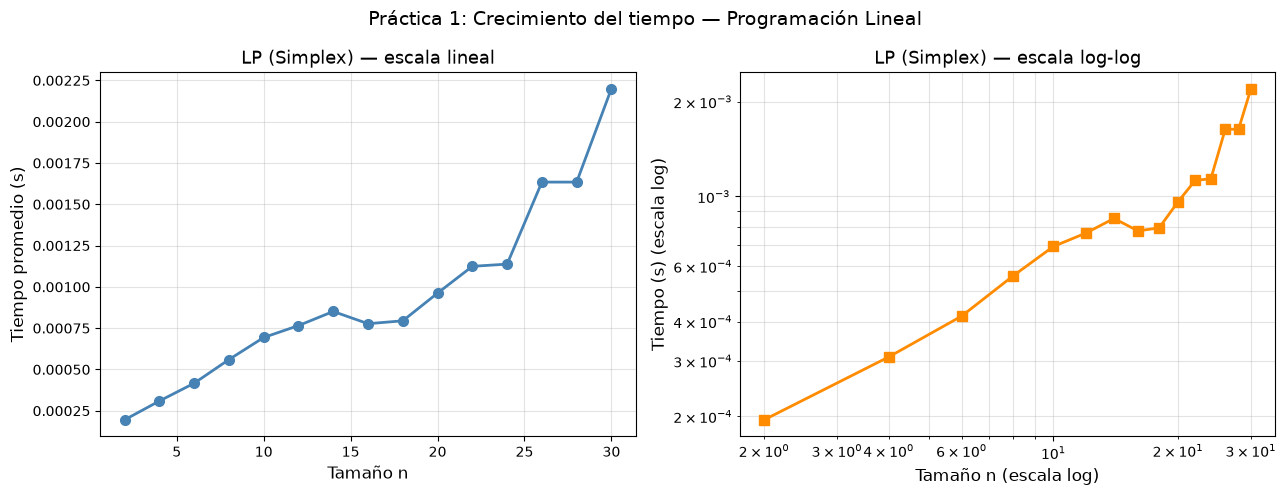

Gráfica guardada como  01_lp_tiempos.png


In [151]:
# ── Celda 7: Gráfica de resultados ───────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Gráfica 1: escala lineal
ax1.plot(tamanos, tiempos_lp, "o-", color="steelblue", linewidth=2, markersize=7)
ax1.set_xlabel("Tamaño n", fontsize=12)
ax1.set_ylabel("Tiempo promedio (s)", fontsize=12)
ax1.set_title("LP (Simplex) — escala lineal", fontsize=13)
ax1.grid(True, alpha=0.35)

# Gráfica 2: escala log-log
# Si la curva es una línea recta en log-log, el crecimiento es tipo y = n^k
ax2.plot(tamanos, tiempos_lp, "s-", color="darkorange", linewidth=2, markersize=7)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Tamaño n (escala log)", fontsize=12)
ax2.set_ylabel("Tiempo (s) (escala log)", fontsize=12)
ax2.set_title("LP (Simplex) — escala log-log", fontsize=13)
ax2.grid(True, which="both", alpha=0.35)

plt.suptitle("Práctica 1: Crecimiento del tiempo — Programación Lineal", fontsize=14)
plt.tight_layout()
plt.savefig("01_lp_tiempos.png", dpi=110, bbox_inches="tight")
plt.show()
print("Gráfica guardada como  01_lp_tiempos.png")

## 7. Preguntas de análisis

Responde en celdas de Markdown nuevas (haz clic en **+ Markdown**).

---

**Q1.** Describe la forma de la curva en la gráfica de escala lineal.
¿Se parece a una recta, a una parábola, a una exponencial? ¿Por qué lo esperarías?

**Q2.** En la gráfica log-log, ¿la curva se aproxima a una recta?
¿Qué indica eso sobre la complejidad del algoritmo?
*(Pista: en escala log-log, $y = n^k$ se ve como una recta de pendiente $k$)*

**Q3.** El método Simplex **no** es polinomial en el peor caso (ejemplo de
Klee-Minty, 1972). Sin embargo, el algoritmo del elipsoide sí lo es.
¿Por qué Simplex sigue siendo el más popular en la práctica?

**Q4.** ¿Qué diferencia fundamental hay entre decir que LP está en **P** y decir
que Simplex "funciona bien empíricamente"? ¿Son la misma afirmación?

**Q5.** Imagina que se demostrara **P = NP**. Menciona dos consecuencias prácticas
en criptografía y dos en optimización combinatoria.

Q1:
    En una vista inicial la curva parece ser una parabola, su crecimiento no es tan regular para asemejar una recta, pero es más gradual de lo que sería una exponencial

Q2:
    A través de varias iteraciones, el crecimiento de la curva si se asemeja a una recta, en cuyo caso describe una curva curva y = n^k, lo que nos diría que el algoritmo tiene ina complejidad polinomial

Q3:
    Aunque en el peor de los casos no es exponencial, se ha analizado que la complejidad promedio de simplex tiende a ser polinomial con la excepcion de algunas funciones lineales\
    Mientras tanto, en la practica, el algoritmo del elipsoide es en promedio maś lento que simplex

Q4:
    Las afirmaciones difieren en que una es el aspecto teorico que busca el "peor de los casos" mientras que el segundo se enfoca en los casos que se encuentran al momento de aplicar simplex a problemas concretos

Q5:
    La gran mayoriá de la encriptacion moderna como es el almacenamiento de contraseñas o metodos como prueba-por-trabajo para alentar o detener spam requieren de resolver problemas NP, si P=NP muchos de la criptografia sería mucho más facil de romper comprometiendo la seguridad de mucha informacion digital\
    En la optimización combinatoria, problemas como el el Problema del Viajero o el Problema de la mochila se podrían resolver en tiempo polinomial, problemas con aplicaciones reales como la logistica de recursos